In [2]:
!pip install transformers torch pillow scikit-learn matplotlib pandas -q

In [3]:
import os
import torch
import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from transformers import ViltProcessor, ViltModel
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Traffic_ViLT_Project(bdd10k)"

IMAGE_DIR = os.path.join(
    DATASET_PATH,
    "images",
    "train"
)

LABEL_DIR = os.path.join(
    DATASET_PATH,
    "labels",
    "train"
)

print("Images Folder Exists:", os.path.exists(IMAGE_DIR))
print("Labels Folder Exists:", os.path.exists(LABEL_DIR))

Images Folder Exists: True
Labels Folder Exists: True


In [9]:
image_files = []

for root, dirs, files in os.walk(IMAGE_DIR):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, f))

label_files = []

for root, dirs, files in os.walk(LABEL_DIR):
    for f in files:
        if f.endswith(".txt"):
            label_files.append(os.path.join(root, f))

image_files = sorted(image_files)
label_files = sorted(label_files)

print("Images:", len(image_files))
print("Labels:", len(label_files))

Images: 7000
Labels: 7011


In [10]:
processor = ViltProcessor.from_pretrained(
    "dandelin/vilt-b32-mlm"
)

model = ViltModel.from_pretrained(
    "dandelin/vilt-b32-mlm"
)

model.eval()

print("ViLT Loaded")

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
mlm_score.bias                       | UNEXPECTED |  | 
mlm_score.decoder.weight             | UNEXPECTED |  | 
mlm_score.transform.dense.weight     | UNEXPECTED |  | 
mlm_score.transform.dense.bias       | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.weight | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ViLT Loaded


In [11]:
def get_embedding(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    inputs = processor(
        images=image,
        text="traffic scene",
        return_tensors="pt"
    )

    with torch.no_grad():

        outputs = model(**inputs)

    embedding = (
        outputs.last_hidden_state[:,0,:]
        .squeeze()
        .numpy()
    )

    return embedding

In [32]:
sample_image = image_files[0]

embedding = get_embedding(sample_image)

print("Embedding Shape:", embedding.shape)

Embedding Shape: (768,)


In [34]:
scene_database = []

selected_indices = np.linspace(
    0,
    len(image_files)-1,
    500,
    dtype=int
)

for idx in selected_indices:

    img_path = image_files[idx]
    lbl_path = label_files[idx]

    embedding = get_embedding(img_path)

    scene_database.append({
        "image": img_path,
        "label": lbl_path,
        "embedding": embedding
    })

print("Database Size:", len(scene_database))

Database Size: 500


In [35]:
def retrieve_similar_scenes(
    query_image,
    top_k=10
):

    query_embedding = get_embedding(query_image)

    scores = []

    for item in scene_database:

        similarity = cosine_similarity(
            [query_embedding],
            [item["embedding"]]
        )[0][0]

        scores.append(
            (item, similarity)
        )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    return scores[:top_k]

In [36]:
query_image = image_files[850]

results = retrieve_similar_scenes(
    query_image,
    top_k=10
)

print("Retrieved:", len(results))

Retrieved: 10


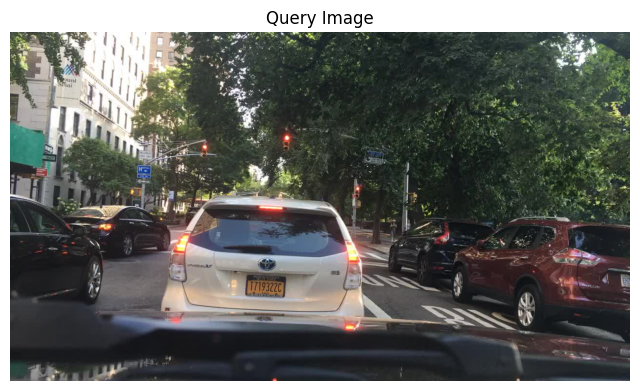

In [37]:
img = Image.open(query_image)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [38]:
def generate_scene_description(
    vehicles,
    persons,
    traffic_lights,
    traffic_signs
):

    if vehicles > 20:
        traffic_desc = "heavy traffic"
    elif vehicles > 10:
        traffic_desc = "moderate traffic"
    else:
        traffic_desc = "light traffic"

    if traffic_lights > 0:
        road_desc = "signalized intersection"
    elif traffic_signs > 3:
        road_desc = "busy urban roadway"
    else:
        road_desc = "city street"

    if persons > 5:
        people_desc = "many pedestrians"
    elif persons > 0:
        people_desc = "some pedestrians"
    else:
        people_desc = "no visible pedestrians"

    return (
        f"{road_desc} with "
        f"{traffic_desc} and "
        f"{people_desc}."
    )

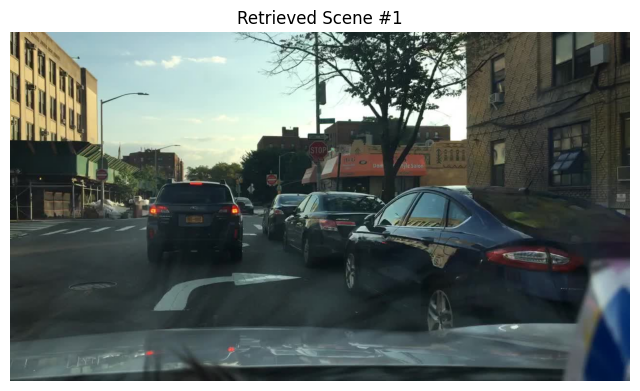

Similarity Score: 99.83%

Scene Description:
city street with moderate traffic and no visible pedestrians.

Detected Objects:
Vehicles: 16
Pedestrians: 0
Traffic Lights: 0
Traffic Signs: 0




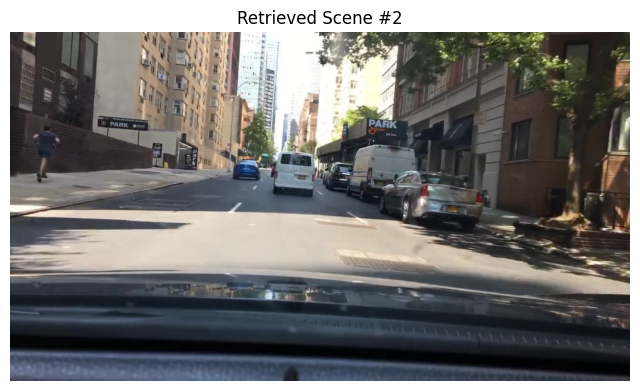

Similarity Score: 99.81%

Scene Description:
busy urban roadway with moderate traffic and no visible pedestrians.

Detected Objects:
Vehicles: 17
Pedestrians: 0
Traffic Lights: 0
Traffic Signs: 4




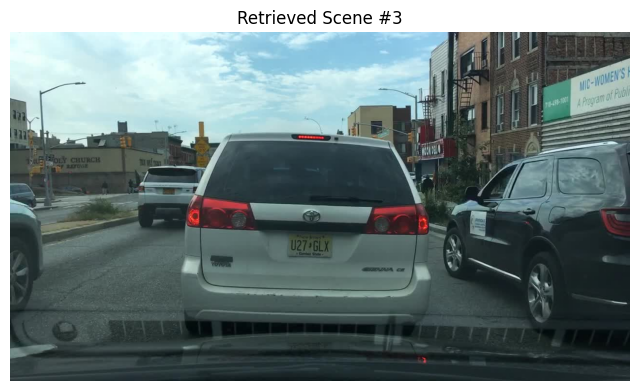

Similarity Score: 99.80%

Scene Description:
city street with moderate traffic and no visible pedestrians.

Detected Objects:
Vehicles: 18
Pedestrians: 0
Traffic Lights: 0
Traffic Signs: 1




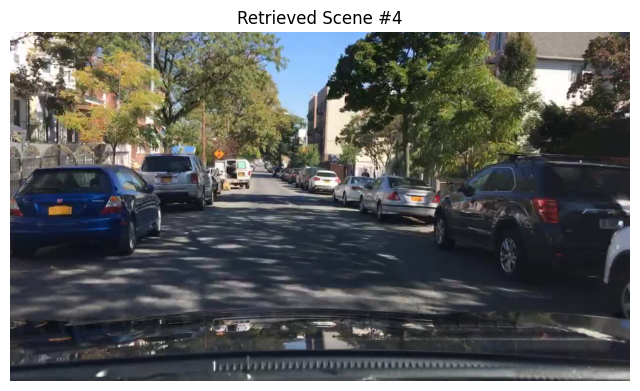

Similarity Score: 99.80%

Scene Description:
busy urban roadway with light traffic and no visible pedestrians.

Detected Objects:
Vehicles: 5
Pedestrians: 0
Traffic Lights: 0
Traffic Signs: 6




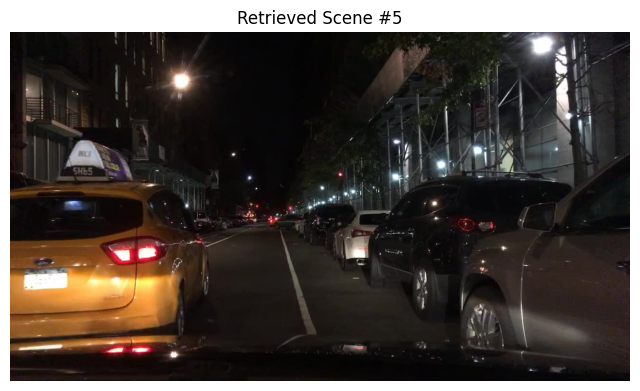

Similarity Score: 99.80%

Scene Description:
busy urban roadway with moderate traffic and no visible pedestrians.

Detected Objects:
Vehicles: 14
Pedestrians: 0
Traffic Lights: 0
Traffic Signs: 4




In [39]:
from PIL import Image
import matplotlib.pyplot as plt

for rank,(item,score) in enumerate(results[:5],1):

    counts = {}

    with open(item["label"],"r") as f:

        for line in f:

            cls = int(line.split()[0])

            counts[cls] = counts.get(cls,0)+1

    cars = counts.get(2,0)
    trucks = counts.get(3,0)
    buses = counts.get(4,0)

    vehicles = cars + trucks + buses

    persons = counts.get(0,0)

    traffic_lights = counts.get(7,0)

    traffic_signs = counts.get(8,0)

    description = generate_scene_description(
        vehicles,
        persons,
        traffic_lights,
        traffic_signs
    )

    img = Image.open(item["image"])

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Retrieved Scene #{rank}")
    plt.show()

    print(f"Similarity Score: {score*100:.2f}%")
    print()

    print("Scene Description:")
    print(description)
    print()

    print("Detected Objects:")
    print(f"Vehicles: {vehicles}")
    print(f"Pedestrians: {persons}")
    print(f"Traffic Lights: {traffic_lights}")
    print(f"Traffic Signs: {traffic_signs}")

    print("\n" + "="*70 + "\n")